In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sns.set_style("darkgrid")

In [3]:
dataset_limpo_medianag = pd.read_csv("./DATASET/dataset_limpo_medianag.csv")
dataset_limpo_medianag.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,Age_Code,Geração
0,1,I am a developer by profession,<18,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,Sem dado,...,10.0,5.0,0.0,0.0,Sem dado,Sem dado,65000.0,7.0,1,Gen Alpha
1,2,I am a developer by profession,35-44,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,Sem dado,Sem dado,65000.0,7.0,4,Millennials/Gen X
2,3,I am a developer by profession,45-54,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,10.0,5.0,0.0,0.0,Appropriate in length,Easy,65000.0,7.0,5,Gen X
3,4,I am learning to code,18-24,"Student, full-time",Sem dado,Apples,Sem dado,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,10.0,5.0,0.0,0.0,Too long,Easy,65000.0,7.0,2,Gen Z
4,5,I am a developer by profession,18-24,"Student, full-time",Sem dado,Apples,Sem dado,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,10.0,5.0,0.0,0.0,Too short,Easy,65000.0,7.0,2,Gen Z


In [5]:
dataset_limpo_medianag["YearsCode"] = dataset_limpo_medianag["YearsCode"].replace({
    "Sem dado": 0,
    "Less than 1 year": 0.5,
    "More than 50 years": 50
})

dataset_limpo_medianag["YearsCode"] = pd.to_numeric(dataset_limpo_medianag["YearsCode"])

dataset_limpo_medianag["YearsCodePro"] = dataset_limpo_medianag["YearsCodePro"].replace({
    "Sem dado": 0,
    "Less than 1 year": 0.5,
    "More than 50 years": 50
})

dataset_limpo_medianag["YearsCodePro"] = pd.to_numeric(dataset_limpo_medianag["YearsCodePro"])

In [27]:
data = dataset_limpo_medianag.select_dtypes(include="number")

data_plot = data[
    (data["ConvertedCompYearly"] > 1000) &
    (data["ConvertedCompYearly"] < 500000)
].copy()

data.columns

Index(['ResponseId', 'YearsCode', 'YearsCodePro', 'CompTotal', 'WorkExp',
       'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6',
       'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat', 'Age_Code'],
      dtype='object')

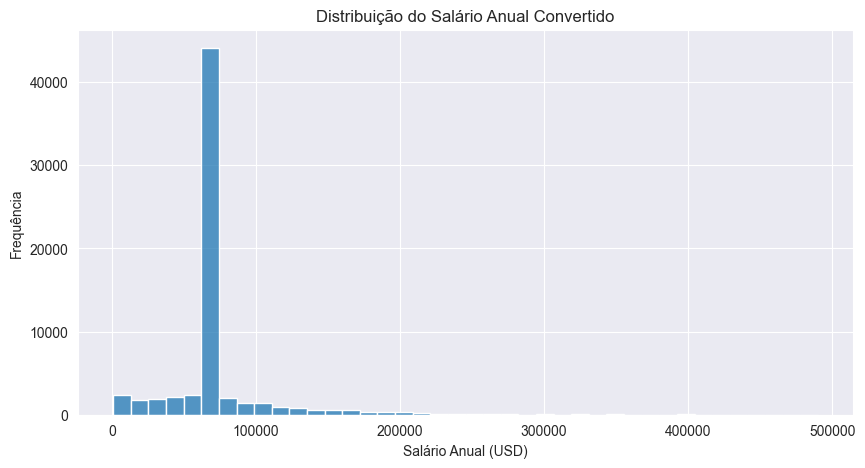

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data_plot["ConvertedCompYearly"], bins=40)
plt.title("Distribuição do Salário Anual Convertido")
plt.xlabel("Salário Anual (USD)")
plt.ylabel("Frequência")
plt.show()

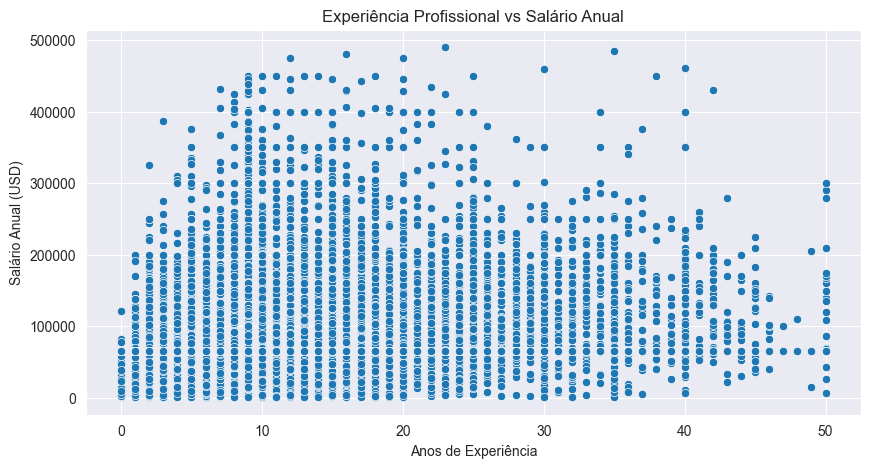

In [9]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data_plot, x="WorkExp", y="ConvertedCompYearly")
plt.title("Experiência Profissional vs Salário Anual")
plt.xlabel("Anos de Experiência")
plt.ylabel("Salário Anual (USD)")
plt.show()

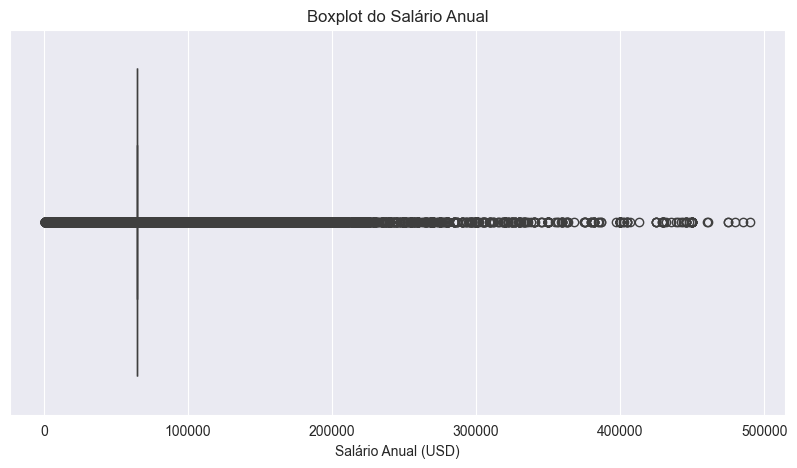

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=data_plot["ConvertedCompYearly"])
plt.title("Boxplot do Salário Anual")
plt.xlabel("Salário Anual (USD)")
plt.show()

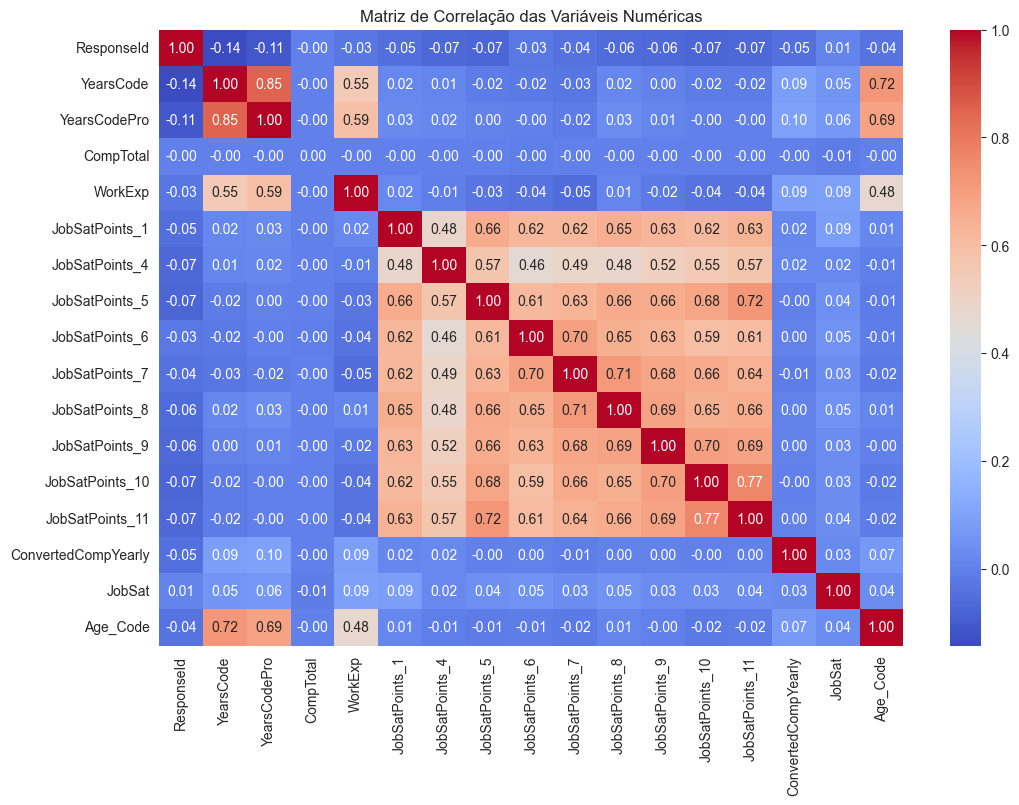

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

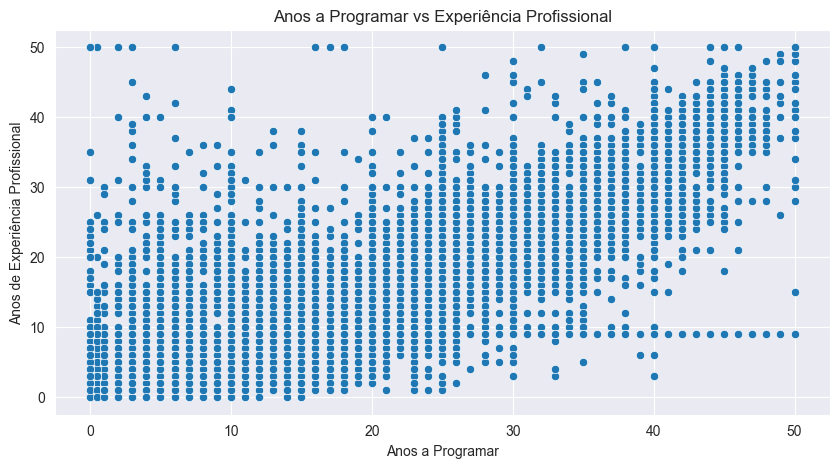

In [12]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x="YearsCode", y="WorkExp")
plt.title("Anos a Programar vs Experiência Profissional")
plt.xlabel("Anos a Programar")
plt.ylabel("Anos de Experiência Profissional")
plt.show()

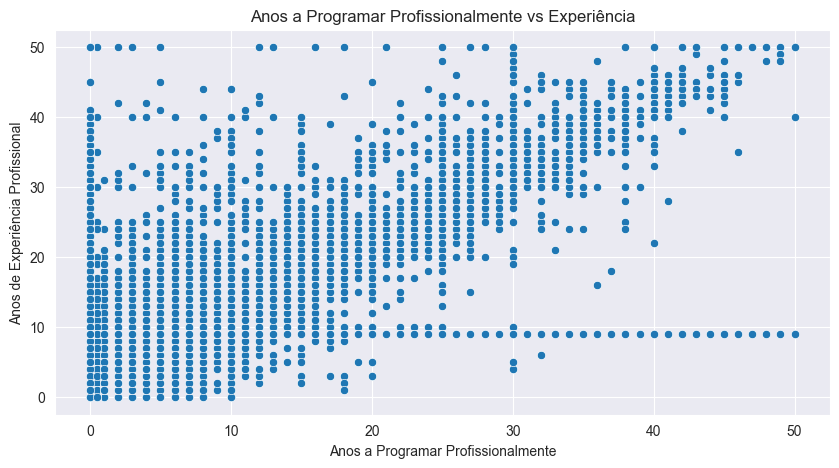

In [13]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x="YearsCodePro", y="WorkExp")
plt.title("Anos a Programar Profissionalmente vs Experiência")
plt.xlabel("Anos a Programar Profissionalmente")
plt.ylabel("Anos de Experiência Profissional")
plt.show()

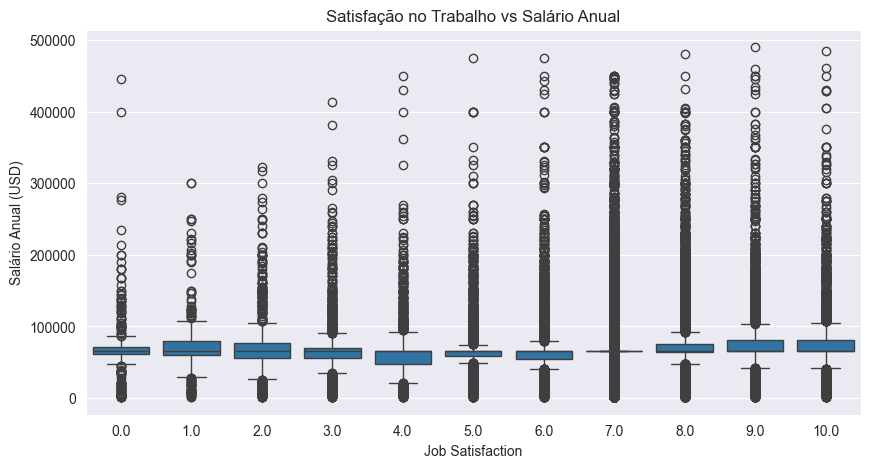

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_plot, x="JobSat", y="ConvertedCompYearly")
plt.title("Satisfação no Trabalho vs Salário Anual")
plt.xlabel("Job Satisfaction")
plt.ylabel("Salário Anual (USD)")
plt.show()

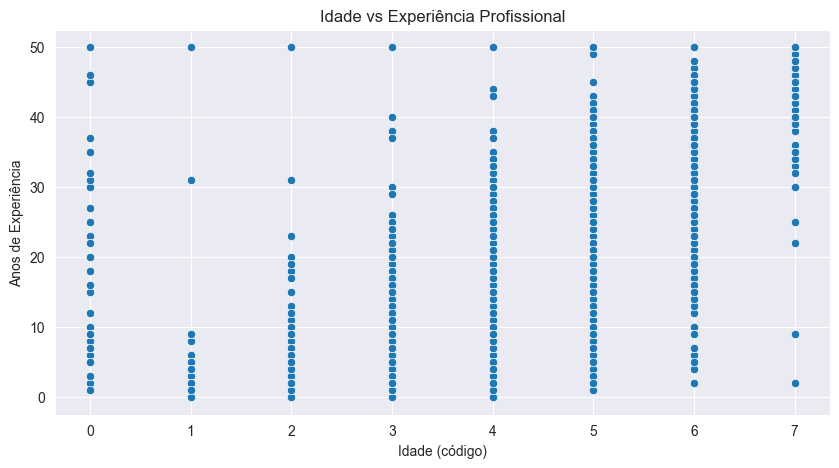

In [15]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x="Age_Code", y="WorkExp")
plt.title("Idade vs Experiência Profissional")
plt.xlabel("Idade (código)")
plt.ylabel("Anos de Experiência")
plt.show()

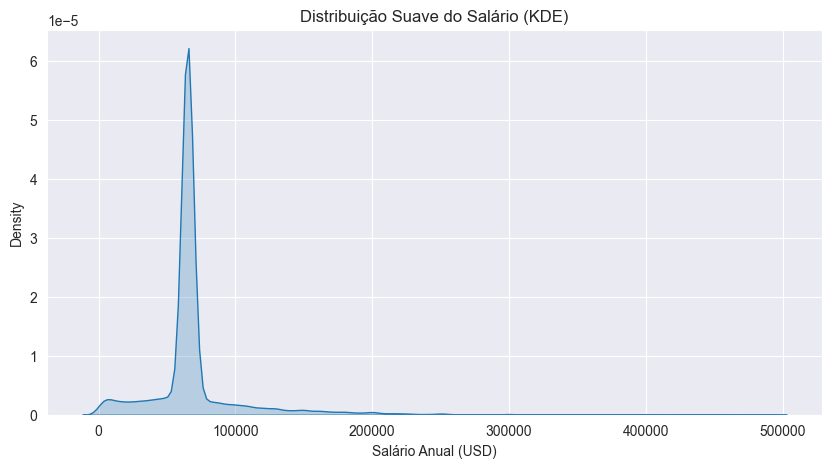

In [17]:
plt.figure(figsize=(10,5))
sns.kdeplot(data_plot["ConvertedCompYearly"], fill=True)
plt.title("Distribuição Suave do Salário (KDE)")
plt.xlabel("Salário Anual (USD)")
plt.show()

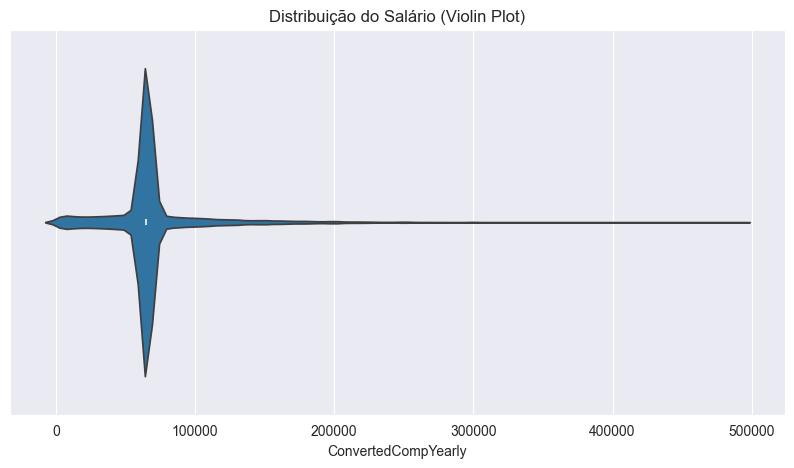

In [18]:
plt.figure(figsize=(10,5))
sns.violinplot(x=data_plot["ConvertedCompYearly"])
plt.title("Distribuição do Salário (Violin Plot)")
plt.show()

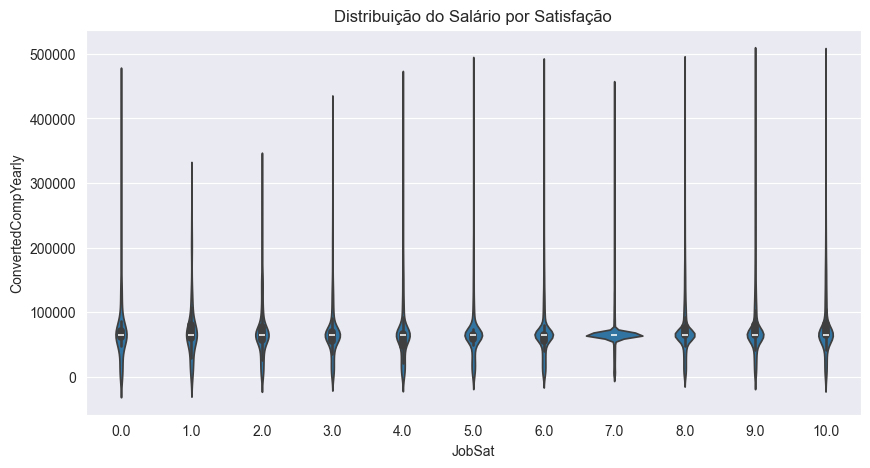

In [19]:
plt.figure(figsize=(10,5))
sns.violinplot(data=data_plot, x="JobSat", y="ConvertedCompYearly")
plt.title("Distribuição do Salário por Satisfação")
plt.show()

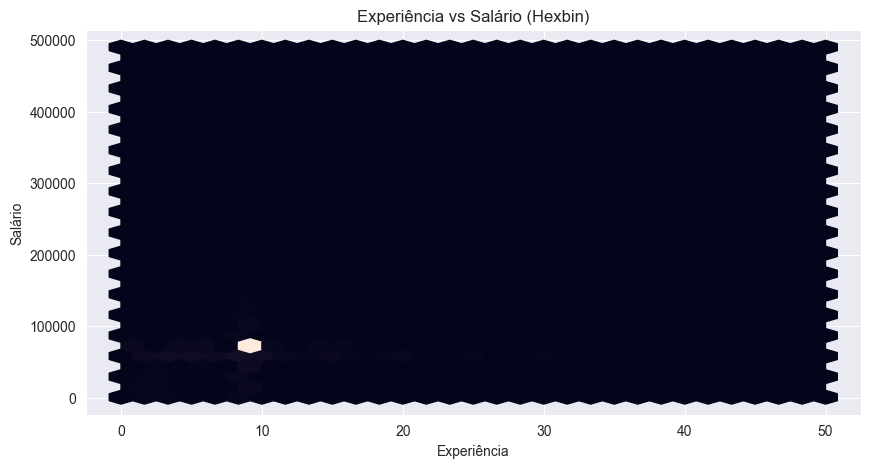

In [20]:
plt.figure(figsize=(10,5))
plt.hexbin(data_plot["WorkExp"], data_plot["ConvertedCompYearly"], gridsize=30)
plt.title("Experiência vs Salário (Hexbin)")
plt.xlabel("Experiência")
plt.ylabel("Salário")
plt.show()

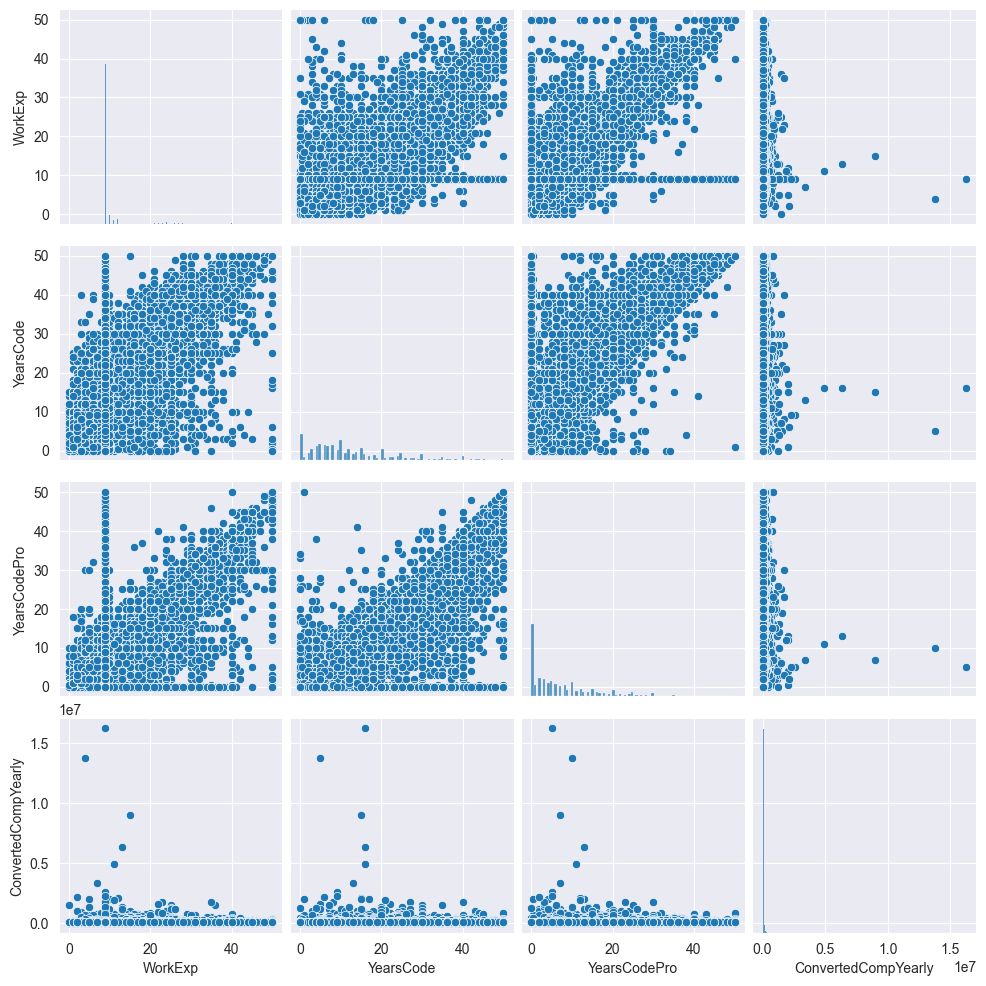

In [21]:
sns.pairplot(data[["WorkExp","YearsCode","YearsCodePro","ConvertedCompYearly"]])
plt.show()

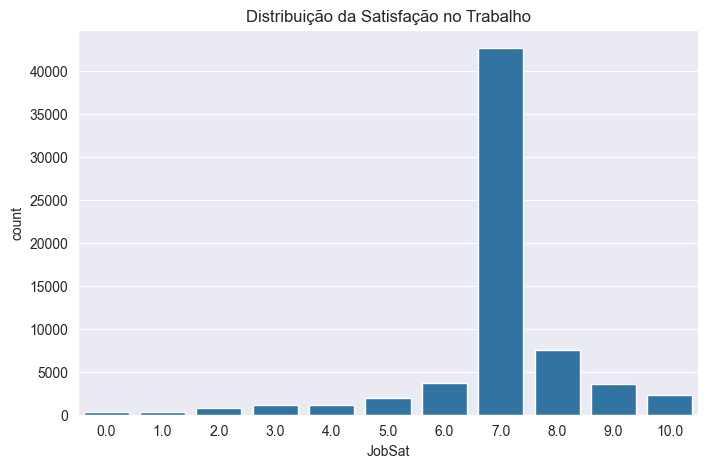

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x=data["JobSat"])
plt.title("Distribuição da Satisfação no Trabalho")
plt.show()

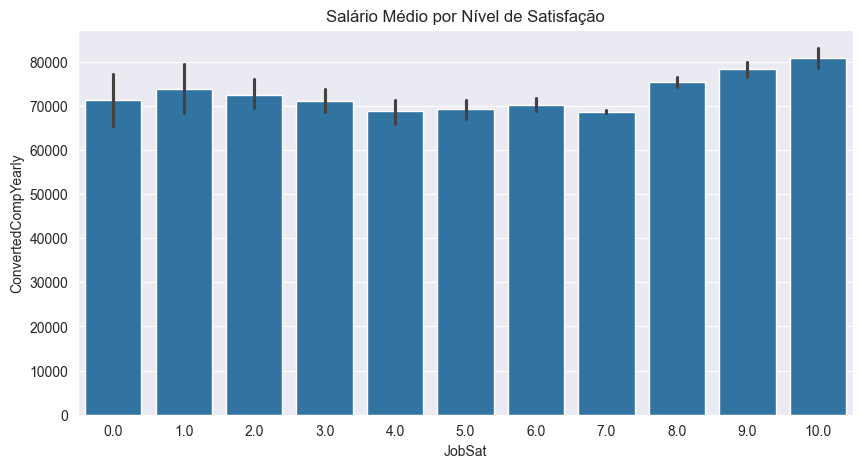

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(data=data_plot, x="JobSat", y="ConvertedCompYearly")
plt.title("Salário Médio por Nível de Satisfação")
plt.show()

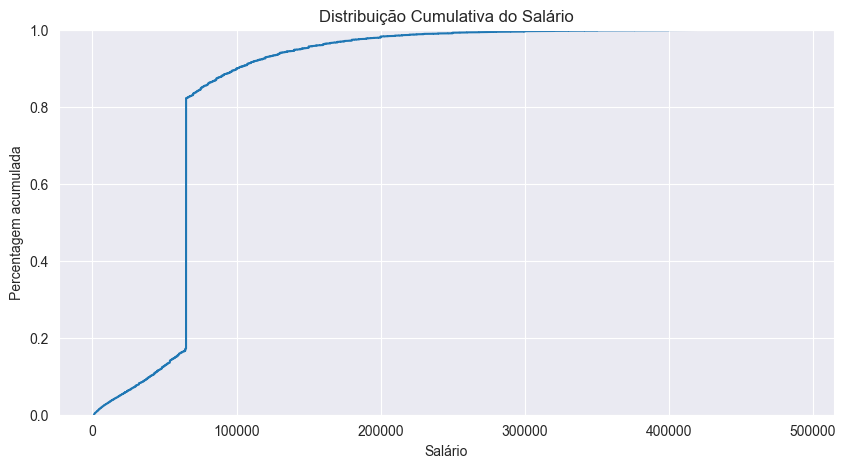

In [24]:
plt.figure(figsize=(10,5))
sns.ecdfplot(data_plot["ConvertedCompYearly"])
plt.title("Distribuição Cumulativa do Salário")
plt.xlabel("Salário")
plt.ylabel("Percentagem acumulada")
plt.show()

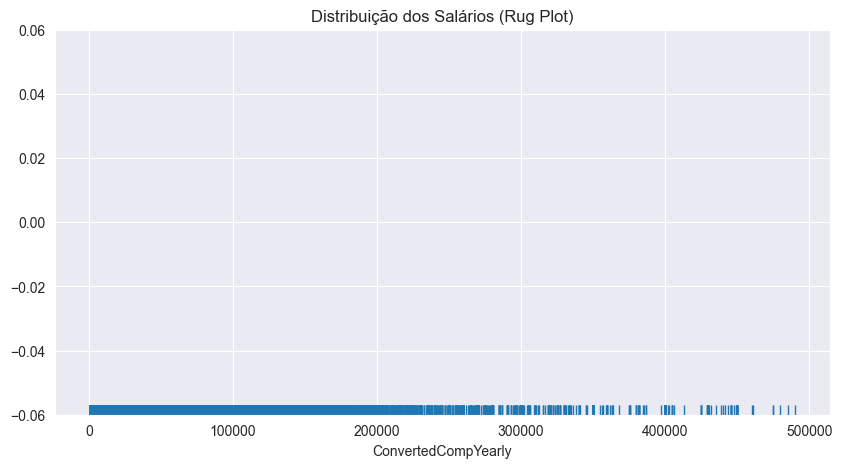

In [25]:
plt.figure(figsize=(10,5))
sns.rugplot(data_plot["ConvertedCompYearly"])
plt.title("Distribuição dos Salários (Rug Plot)")
plt.show()

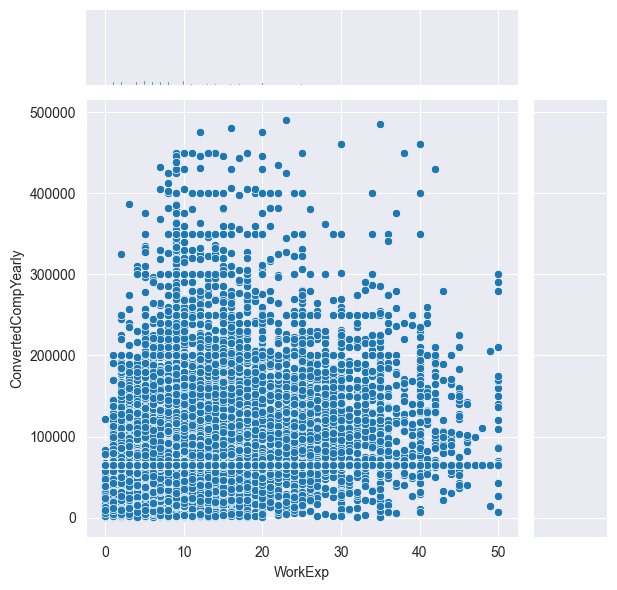

In [26]:
sns.jointplot(data=data_plot, x="WorkExp", y="ConvertedCompYearly", kind="scatter")
plt.show()

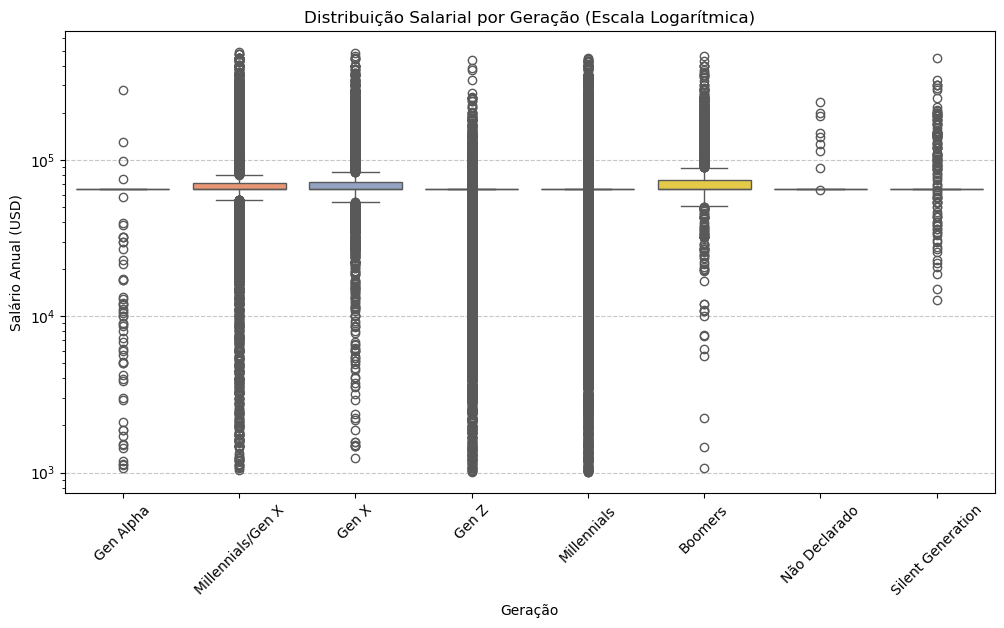

In [9]:
# 1. Filtrar o dataset do colega para excluir valores nulos ou extremos
# Usamos o intervalo de 1.000 a 500.000 para maior clareza visual
df_plot = dataset_limpo_medianag[
    (dataset_limpo_medianag['ConvertedCompYearly'] > 1000) & 
    (dataset_limpo_medianag['ConvertedCompYearly'] < 500000)
].copy()

# 2. Criar o gráfico
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='Geração', y='ConvertedCompYearly', hue='Geração', palette='Set2', legend=False)

# 3. Ajustar escala para logarítmica (essencial para dados salariais)
plt.yscale('log') 

plt.title('Distribuição Salarial por Geração (Escala Logarítmica)')
plt.xlabel('Geração')
plt.ylabel('Salário Anual (USD)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.show()

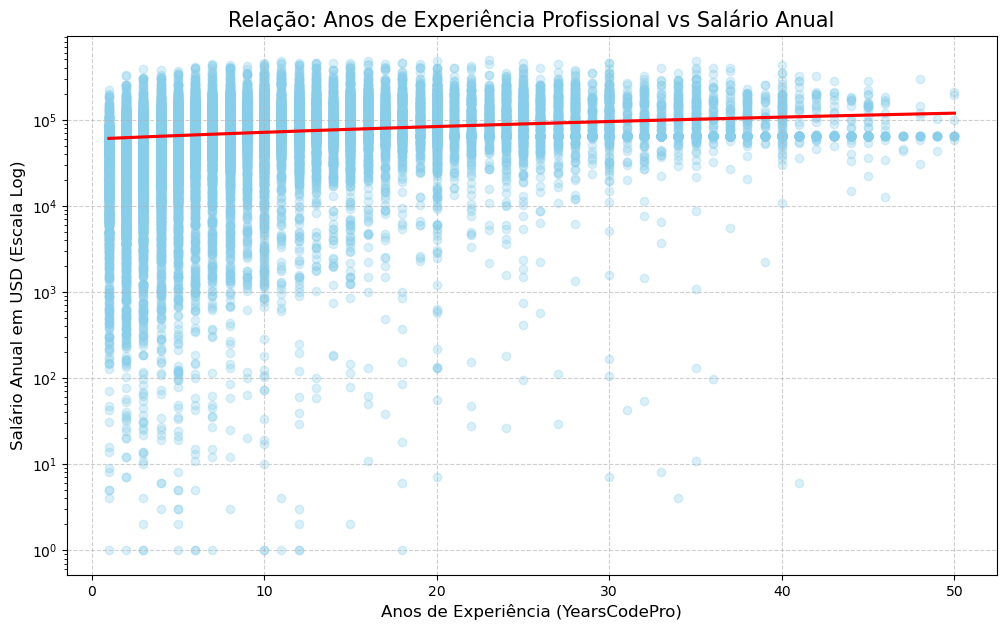

In [11]:
# 1. Preparar os dados (remover nulos nas duas colunas para o gráfico não quebrar)
# Usamos o 'dataset_limpo_medianag' que é o nome correto no teu ficheiro
df_exp_sal = dataset_limpo_medianag.dropna(subset=['YearsCodePro', 'ConvertedCompYearly']).copy()

# Garantir que os anos de experiência são números (caso estejam como texto)
df_exp_sal['YearsCodePro'] = pd.to_numeric(df_exp_sal['YearsCodePro'], errors='coerce')

# 2. Filtrar outliers para o gráfico ser legível (ex: salários até 500k)
df_exp_sal = df_exp_sal[df_exp_sal['ConvertedCompYearly'] < 500000]

# 3. Criar o gráfico de Experiência vs Salário
plt.figure(figsize=(12, 7))

sns.regplot(data=df_exp_sal, 
            x='YearsCodePro', 
            y='ConvertedCompYearly', 
            scatter_kws={'alpha':0.3, 'color':'skyblue'}, 
            line_kws={'color':'red'})

# 4. Ajustes de escala e títulos
plt.yscale('log') # Escala logarítmica no salário para melhor visualização
plt.title('Relação: Anos de Experiência Profissional vs Salário Anual', fontsize=15)
plt.xlabel('Anos de Experiência (YearsCodePro)', fontsize=12)
plt.ylabel('Salário Anual em USD (Escala Log)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

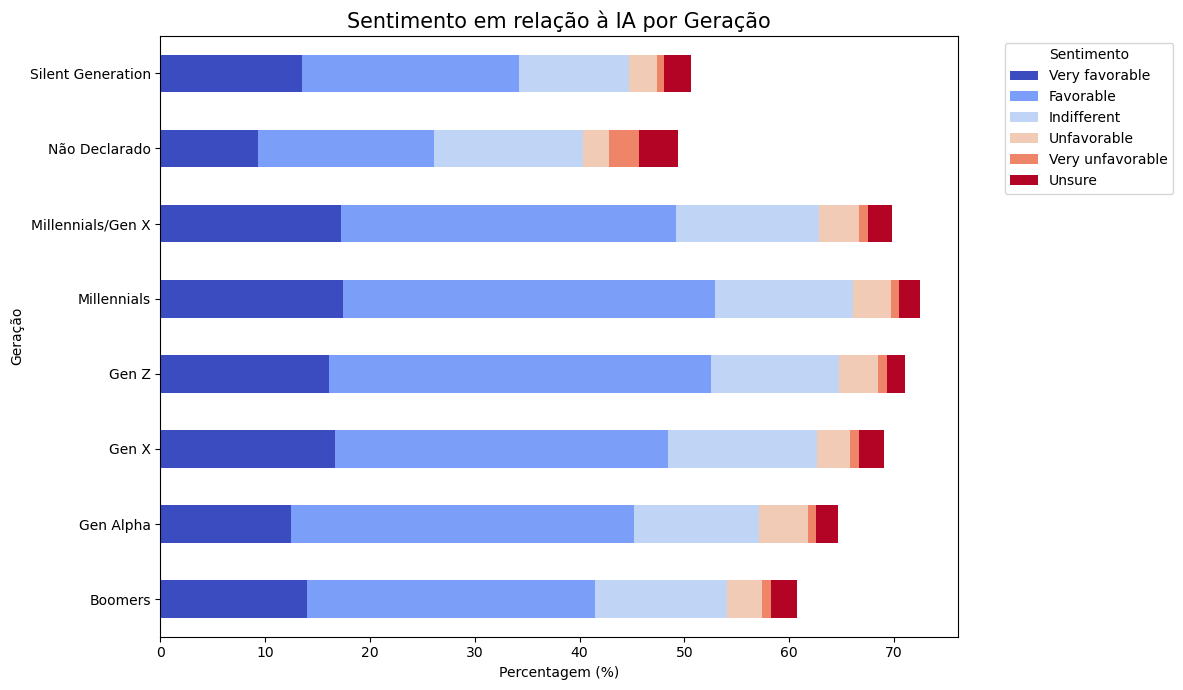

In [12]:
# --- Análise de Sentimento sobre IA por Geração ---

# 1. Limpar dados: Remover quem não respondeu à pergunta sobre IA (AISent)
# Usamos o dataset_limpo_medianag que é o padrão do teu colega
df_ai = dataset_limpo_medianag[dataset_limpo_medianag['AISent'].notnull()].copy()

# 2. Criar uma tabela de cruzamento (Geração vs Sentimento)
# normalize='index' é fundamental para comparar gerações com números de pessoas diferentes
ai_analysis = pd.crosstab(df_ai['Geração'], df_ai['AISent'], normalize='index') * 100

# 3. Ordenar os sentimentos para uma leitura lógica (do mais positivo ao mais negativo)
# Verifiquei as categorias padrão do Stack Overflow
ordem_sentimento = ['Very favorable', 'Favorable', 'Indifferent', 'Unfavorable', 'Very unfavorable', 'Unsure']
# Filtramos apenas as que existem no teu dataset para evitar erros
ordem_existente = [sent for sent in ordem_sentimento if sent in ai_analysis.columns]
ai_analysis = ai_analysis.reindex(columns=ordem_existente)

# 4. Desenhar o gráfico de barras empilhadas (Stacked Bar Chart)
ai_analysis.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='coolwarm')

plt.title('Sentimento em relação à IA por Geração', fontsize=15)
plt.xlabel('Percentagem (%)')
plt.ylabel('Geração')
# Coloca a legenda fora do gráfico para não tapar as barras
plt.legend(title='Sentimento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

--- Percentagem de Uso de IA por Geração ---
AISelect           No, and I don't plan to  No, but I plan to soon  Sem dado  \
Geração                                                                        
Boomers                              35.69                   21.36      3.50   
Gen Alpha                            27.06                    9.15      7.87   
Gen X                                26.88                   18.63      3.95   
Gen Z                                18.85                    7.92      9.57   
Millennials                          19.89                   12.02      7.32   
Millennials/Gen X                    24.49                   15.26      5.47   
Não Declarado                        36.02                   11.80     13.98   
Silent Generation                    45.60                   19.69      3.63   

AISelect             Yes  
Geração                   
Boomers            39.46  
Gen Alpha          55.92  
Gen X              50.54  
Gen Z              

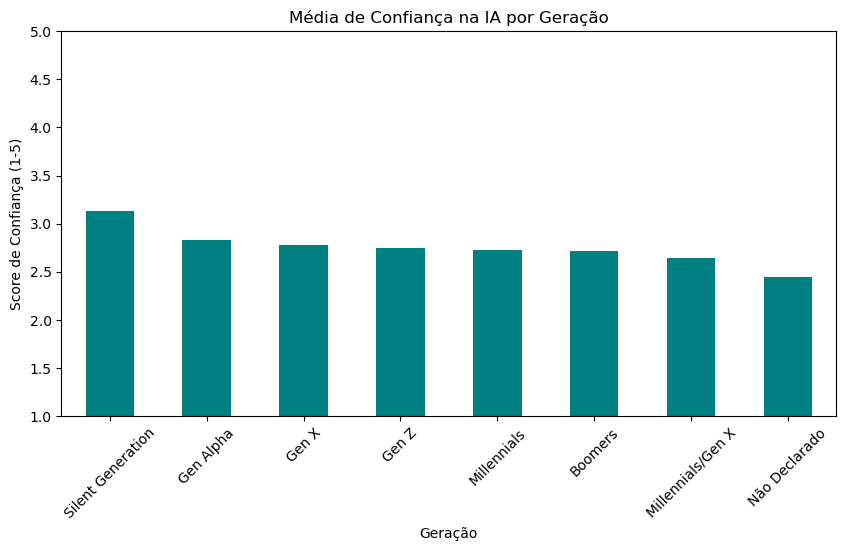

In [13]:
# --- Análise de Uso e Confiança na IA por Geração ---

# 1. Percentagem de Uso de IA por Geração
# Usamos 'dataset_limpo_medianag'
uso_ia = pd.crosstab(dataset_limpo_medianag['Geração'], dataset_limpo_medianag['AISelect'], normalize='index') * 100

# 2. Criar um Score Numérico para a Confiança (AIAcc)
# Isto permite calcular uma média (ex: a Gen Z confia 4.2 em 5)
confianca_map = {
    'Highly trust': 5,
    'Trust': 4,
    'Neither trust nor distrust': 3,
    'Distrust': 2,
    'Highly distrust': 1
}

# Criamos a nova coluna no dataset do colega
dataset_limpo_medianag['AI_Trust_Score'] = dataset_limpo_medianag['AIAcc'].map(confianca_map)

# Calcular a média por geração
confianca_gen = dataset_limpo_medianag.groupby('Geração')['AI_Trust_Score'].mean().sort_values(ascending=False)

# 3. Exibir os resultados
print("--- Percentagem de Uso de IA por Geração ---")
print(uso_ia.round(2)) # round(2) para não ter demasiadas casas decimais
print("\n--- Média de Confiança na IA (Escala 1-5) ---")
print(confianca_gen.round(2))

# --- BÓNUS: Gráfico rápido de Confiança ---
plt.figure(figsize=(10, 5))
confianca_gen.plot(kind='bar', color='teal')
plt.title('Média de Confiança na IA por Geração')
plt.ylabel('Score de Confiança (1-5)')
plt.ylim(1, 5) # A escala vai de 1 a 5
plt.xticks(rotation=45)
plt.show()